# Trees
### `! git clone https://github.com/ds4e/trees`

## Trees
- We've looked at two models -- $k$-NN, general linear models -- that offer different approaches to machine learning:
    - $k$-NN: Local, case-based smoothing
    - General Linear: Global, variable-based smoothing
- Now we'll consider is called a *classification/regression tree* or often a *decision tree*, a supervised learning algorithm for regression and classification
- This method is somewhere in between local and global smoothing: It recursively and greedily "splits" the sample to partition the data to minimize differences in outcomes within the groups 
- Later, a group of trees built in a stochastic way becomes a random forest, so it's worth understanding how trees work

## Regression Tree
- Here's an example of a regression tree from later predicting heart failure. If the box is true, go left; otherwise right:
**The decision is the first line. The value is prediction.**

<img src="./src/tree.png" width="550">

## Classification Tree

- Here's an example of a classification tree from later predicting which animal class a species belongs to. If the box is true, go left; otherwise right:

<img src="./src/species.png" width="550">

## Trees
- There are $N$ observations of data $X$ and outcomes $y$ (supervised learning: same setup as $k$-NN and linear models)
- We want to use $X$ to predict $\hat{y}$ for future cases $\hat{x}$
- A *classification/regression/decision tree* is
  1. A set of *decision nodes* that represent decision points
  2. A set of edges that represent *choices* at each decision node (data-driven choices)
  3. A set of *terminal nodes* or *outcomes* at the bottom of the tree (predictions or courses of action)
- The goal is to build a tree from data that predicts outcomes (classification or regression) for future cases

# 1. Classification Example

## Divorce Data
- There are 54 questions, with Likert-scale-type 0--4 response values (0=Strongly Agree, 1=Agree, 2=Neutral, 3=Disagree, 4=Never), and an outcome of divorce/married
- You *could* make this into a linear model by interacting all of the pairs and triples and tuples of the questions together, but it would be wildly overfit and uninterpretable. It's unclear what $k$-NN would be doing, since the "distances" are arbitrary and using the Euclidean distance would weight all of the questions equally (some are pretty trivial)
- Instead, you can fit a decision tree to predict marriage outcomes on the basis of the questions, which seems much more natural and reliable
- In diagnostic settings, this is extremely popular

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/divorce/divorce_data.csv',sep=';') # Load divorce data
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Divorce
0,2,2,4,1,0,0,0,0,0,0,...,2,1,3,3,3,2,3,2,1,1
1,4,4,4,4,4,0,0,4,4,4,...,2,2,3,4,4,4,4,2,2,1
2,2,2,2,2,1,3,2,1,1,2,...,3,2,3,1,1,1,2,2,2,1
3,3,2,3,2,3,3,3,3,3,3,...,2,2,3,3,3,3,2,2,2,1
4,2,2,1,1,1,1,0,0,0,0,...,2,1,2,3,2,2,2,1,0,1


In [4]:
from sklearn.tree import DecisionTreeClassifier # Import the tree classifier
from sklearn.tree import plot_tree # Plot the tree

# Process data:
y = df['Divorce'] # Target variable
X = df.drop(['Divorce'], axis=1) # Features/predictors

# Fit decision tree:
cart = DecisionTreeClassifier() # Create a classifier object
cart = cart.fit(X, y) # Fit the classifier

[Text(0.6666666666666666, 0.875, 'Q18 <= 1.5\ngini = 0.5\nsamples = 170\nvalue = [86, 84]'),
 Text(0.5, 0.625, 'Q26 <= 1.5\ngini = 0.065\nsamples = 89\nvalue = [86, 3]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'Q40 <= 2.5\ngini = 0.023\nsamples = 87\nvalue = [86, 1]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 86\nvalue = [86, 0]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 81\nvalue = [0, 81]'),
 Text(0.75, 0.75, '  False')]

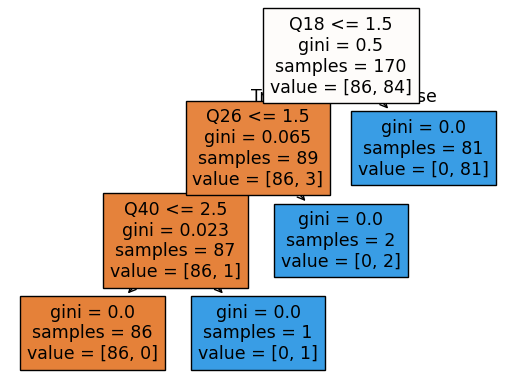

In [5]:
# Visualize results:
var_names = cart.feature_names_in_
plot_tree(cart,filled=True,feature_names=var_names) 

**The bottom two are perfectly separated. This is overfitting because the model is making too big of a decisions.**

## Selected Questions
- Decision trees are typically represented with a *dendrogram*, the plot on the previous slide; these are a popular way of visualizing hierarchical or acyclic relationships:
    - 18. My spouse and I have similar ideas about how marriage should be (High value/"Never" predicts divorce)
    - 26. I know my spouse's basic concerns. (High value/"Never" predicts divorce)
    - 40. We are just starting a fight before I know what is going on. (High value/"Never" predicts divorce)
- Seems about right? Maybe the last question is overfitting?

## Did it "work"?
- Recall the confusion matrix:

|  | Predicted Negative | Predicted Positive|
| :---: | :---:| :---: |
| Actual Negative | True Negative (TN) | False Positive (FP) |
| Actual Positive | False Negative (FN) | True Positive (TP) |

- The simplest metric of success with a confusion table is **Accuracy**: The proportion of predictions that were correct, or
$$ \text{Accuracy} = \dfrac{TN+TP}{TN+FP+FN+TP} = \dfrac{TN+TP}{N} $$

## Performance Evaluations
- Remember, we don't want to evaluate the models on the data on which they were trained; this leads to overfitting
- In order to evaluate model performance, we can use a train/test split, or $k$-fold cross validation

In [6]:
## Splitting the Sample into Train/Test Sets:
from sklearn.model_selection import train_test_split

## Preprocess Data:
y = df['Divorce']
X = df.drop(['Divorce'], axis=1)

## Split the Sample into Training and Testing Sets:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=104)

## Fit the Model:
from sklearn import tree # Import the tree classifier
cart = tree.DecisionTreeClassifier() # Create a classifier object
cart = cart.fit(X_train, y_train) # Fit the classifier

## Make Predictions on the Test Set:
y_hat = cart.predict(X_test)

In [7]:
## Confusion Matrix:
tab = pd.crosstab(y_test,y_hat) # Compute confusion matrix
acc = (tab.iloc[0,0]+tab.iloc[1,1])/len(y_test) # Compute Accuracy
#acc = np.trace(tab)/len(y_test)  # Faster way to compute accuracy
print('Accuracy: ', acc, '\n')
pd.crosstab(y_test,y_hat)

Accuracy:  0.9117647058823529 



col_0,0,1
Divorce,,
0,15,1
1,2,16


## $k$-Fold Cross Validation

In [8]:
## 10-Fold Cross Validation:
from sklearn.model_selection import cross_val_score
from sklearn import tree  # Import the tree classifier

## Preprocess Data:
y = df['Divorce']
X = df.drop(['Divorce'], axis=1)

In [9]:
## Create the Model:
cart = tree.DecisionTreeClassifier(random_state=104)

## Run 10-Fold Cross Validation:
cv_scores = cross_val_score(cart, X, y, cv=10)

## View the Accuracy for Each Fold:
print(cv_scores)

## View the Mean Accuracy:
print("Mean accuracy:", cv_scores.mean())


[0.82352941 1.         1.         1.         1.         1.
 1.         0.94117647 1.         0.88235294]
Mean accuracy: 0.9647058823529413


In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree

## Preprocess Data:
y = df['Divorce']
X = df.drop(['Divorce'], axis=1)

## Create the Model:
cart = tree.DecisionTreeClassifier(random_state=104)

## Get 10-Fold Cross-Validated Predictions:
y_hat = cross_val_predict(cart, X, y, cv=10)

## Compute Confusion Matrix:
cm = confusion_matrix(y, y_hat)
print(cm)

[[83  3]
 [ 3 81]]


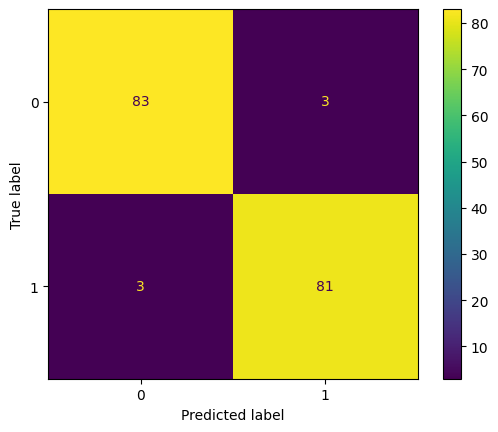

In [11]:
ConfusionMatrixDisplay.from_predictions(y, y_hat)

## Examples
- Diagnostic tests in medical settings (symptoms/test results $\rightarrow$ diagnosis; doctors love trees)
- Any situation where most of the data are mostly categorical rather than numeric
- High-dimensional data where variable selection for linear model is too difficult or where the arbitrariness of the distance metric in $k$-NN is a concern

## Gini and Entropy
- How are the splits being done?
- Let's say the observations are `Apples` or `Oranges` and the variable is `Color`
- We're trying to find a shade of red/orange/yellow that breaks the fruit into two groups, where one group is mostly apples and the other is mostly oranges
- We don't want **mixing** or **impurity** of the split: If both groups are 50/50 apples/oranges after the split, it's not worth doing

<img src="./src/apples_and_oranges.png" width="550">

## Gini and Entropy
- Quantitatively, how do we express a preference for better classified groups?
- Let $a$ be the proportion of apples, so that $o=1-a$ is the proportion of oranges

1. The **Gini impurity** is given by
$$
G = 1 - (a^2 + o^2) = 2a(1-a)
$$
2. The **Entropy** is given by
$$
H = -a \log(a) - o \log(o) = -a \log(a) - (1-a) \log(1-a)
$$

Both of these are classic ways of expressing the "disorder" in a system, are visually similar, and faithfully represent our preferences for "separation"

In [12]:
def ent(p):
    """Entropy function (binary)."""
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

p_grid = np.linspace(0,1,100)

Entropy = [ ent(p) for p in p_grid ]
Gini = 2*p_grid*(1-p_grid)

Text(0.5, 0, 'a')

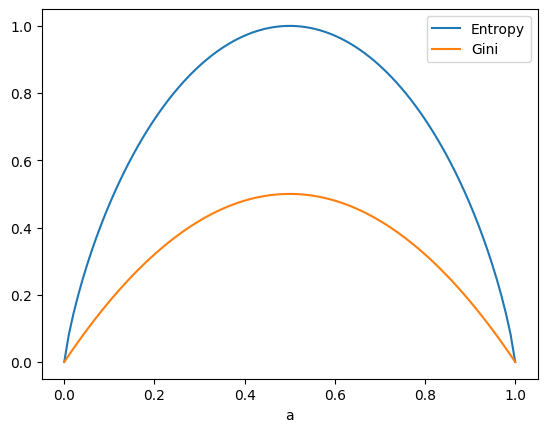

In [13]:
sns.lineplot(x=p_grid,y=Entropy,label='Entropy')
sns.lineplot(x=p_grid,y=Gini,label='Gini')
plt.xlabel('a')

## 2. Regression Example

## Regression Trees and Numeric Regressors
- What if the outcome, $y$, is numeric rather than categorical?
- Trees can work well for regression as well: Don't mistake my enthusiasm for classification applications to mean that they're not useful for regression as well
- We can use the MSE/SSE on either side of the split to choose where to split:

  1. Pick a split point, $s$ for the numeric predictor/regressor $x$
  2. On either side of the split, compute the mean values of the outcome, $\bar{y}_L(s)$ and $\bar{y}_R(s)$
  3. Compute the SSE for the split $s$:
$$
\text{SSE}(s) = \underbrace{\sum_{x<s} (y(x) - \bar{y}_L(s))^2}_{\text{Left SSE}} + \underbrace{\sum_{x \ge s} (y(x)-\bar{y}_R(s))^2}_{\text{Right SSE}}
$$
  4. Choose $s$ to minimize `SSE(s)`

- As we move down the tree, the goal is to reduce the `SSE` along each split/path; stopping rules become critical with numeric outcomes  
- Likewise, this allows the split variable $s$ to be numeric or categorical: Minimization over its values is typically easy to do (e.g. Assignment 1)

## A Regression Example
- We can regress prices on apartment features using the AirBnB data
- The goal is to illustrate regression using trees: They're not just for classification, even if they excel at that task

In [14]:
from sklearn.tree import DecisionTreeRegressor # Import the tree classifier
from sklearn.tree import plot_tree # Import the tree classifier
from sklearn.model_selection import train_test_split # Train/test splitter

df = pd.read_csv('./data/airbnb_hw.csv') # Load airbnb data
df['Price'] = pd.to_numeric(df['Price'].str.replace(',',''), errors='coerce') # Clean price
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


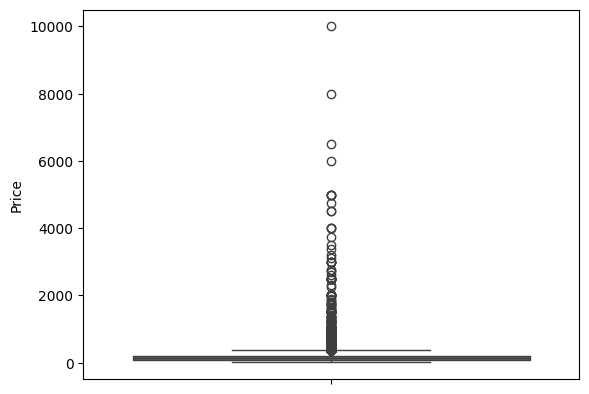

In [15]:
sns.boxplot(df['Price'])
plt.show()


In [16]:
def winsorize(x):
    # Convert from pd to np, if necessary:
    if type(x) == 'pandas.core.series.Series':
        x = x.to_numpy()
    # Compute IQR and 25, 75 quantiles:
    pct25, pct75 = np.percentile(x,[25,75])
    iqr = pct75 - pct25
    # Compute whiskers:
    lower_whisker = pct25 - iqr*1.5
    upper_whisker = pct75 + iqr*1.5
    # Windorize x:
    x_winsor = np.copy(x)
    x_winsor[ x < lower_whisker ] = lower_whisker
    x_winsor[ x > upper_whisker ] = upper_whisker
    return(x_winsor)

<Axes: ylabel='Price'>

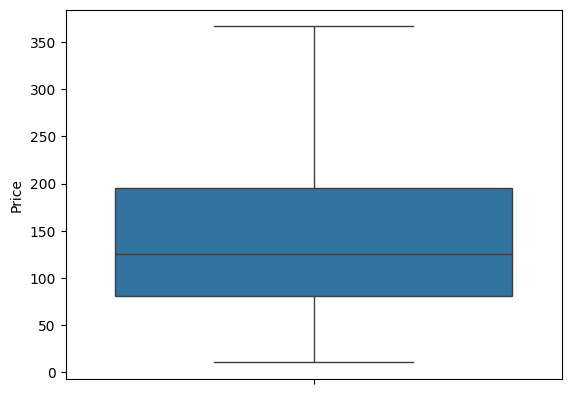

In [17]:
df['Price'] = winsorize(df['Price']) # Winsorize x?
sns.boxplot(df['Price'])

In [18]:
# Process data:
y = df['Price'] 
#y =  np.log(df['Price']) # Compare with log version
#print(y.describe())

# Dummy variables:
type_dummy = pd.get_dummies(df['Property Type'])
room_dummy = pd.get_dummies(df['Room Type'])
nbhd_dummy = pd.get_dummies(df['Neighbourhood '])

vars = ['Beds','Number Of Reviews']
X = pd.concat([df.loc[:,vars], type_dummy, nbhd_dummy, room_dummy],axis=1)

# Train-test split:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=100)


In [ ]:
# Fit decision tree:
cart = DecisionTreeRegressor(min_samples_leaf = 2500) # Create a regression object
#cart = DecisionTreeRegressor(max_depth = 2500)
cart = cart.fit(X_train, y_train) # Fit the regression

## Make Predictions on the Test Set
y_hat = cart.predict(X_test)

[Text(0.4583333333333333, 0.875, 'Entire home/apt <= 0.5\nsquared_error = 7189.04\nsamples = 24382\nvalue = 147.767'),
 Text(0.25, 0.625, 'Manhattan <= 0.5\nsquared_error = 1893.131\nsamples = 10744\nvalue = 89.269'),
 Text(0.35416666666666663, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'Number Of Reviews <= 1.5\nsquared_error = 1117.84\nsamples = 6176\nvalue = 76.728'),
 Text(0.08333333333333333, 0.125, 'squared_error = 1512.623\nsamples = 2664\nvalue = 78.726'),
 Text(0.25, 0.125, 'squared_error = 813.057\nsamples = 3512\nvalue = 75.213'),
 Text(0.3333333333333333, 0.375, 'squared_error = 2441.195\nsamples = 4568\nvalue = 106.225'),
 Text(0.6666666666666666, 0.625, 'Manhattan <= 0.5\nsquared_error = 6541.536\nsamples = 13638\nvalue = 193.851'),
 Text(0.5625, 0.75, '  False'),
 Text(0.5, 0.375, 'Number Of Reviews <= 3.5\nsquared_error = 5234.035\nsamples = 5424\nvalue = 164.452'),
 Text(0.4166666666666667, 0.125, 'squared_error = 5630.57\nsamples = 2624\nvalue = 165.313'),
 Te

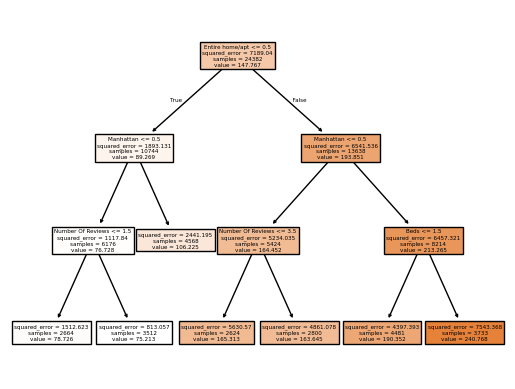

In [20]:
# Visualize results:
var_names = cart.feature_names_in_
plot_tree(cart,filled=True,feature_names=var_names)

**A symmetrical tree is not good.**

## Stopping Rules
- Overfitting with trees is really common, and the structure of trees provides a variety of strategies to avoid overfit models:
  - Impose a limit on the depth of the tree: The maximum length of a path from the top to the bottom (`max_depth`) **always set max depth**
  - Impose a lower bound on the impurity that can appear at a terminal node: Don't allow the terminal nodes to be "too pure" (`min_impurity_decrease`)
  - Impose a limit on how few cases can appear at a terminal node: Don't allow the terminal nodes to be "too small" (`min_samples_leaf`)
- Imposing a constraint on the max depth is the easiest thing to do: It imposes a hard limit on how many levels the tree can have, but often leads to a very "symmetric" and often flawed predictor
- Constraining the min impurity or min samples per leaf, instead, allow the tree to go deep when the data are very discerning of the outcome, but also shallow when the data isn't very helpful for differentiating outcomes in $y$ 
- We're going to "play" with the stopping rules to see what they do to tree shape
- Early stopping is a form of **regularization**: Imposing constraints on the model to force it not to overfit 

## Conclusion: Trees
- There are dozens of variations on this concept (e.g. ID3, C4.5, CART)
- They express highly non-linear relationships between target variables and data: This can be an advantage in some situations over linear models
- Many people like how "interpretable" they are: This can be an advantage over $k$-NN
- They are famously sensitive to the data (a later algorithm, random forests, will address this problem)
- They are based on discrete splits --- this is simple but works very well on "chunky"/"unitless" data like the divorce Likert scale questions
- Prediction can be a challenge if the resulting model is "too simple" --- imagine a therapist asking two questions, telling you to get divorced, and asking for payment